# Machine Learning Foundations for Risk and Finance
## Week 3 - Support Vector Machines & Unsupervised Learning
### Margins, Kernels, and Finding Structure Without Labels

This week has two halves that look unrelated and are held together by one idea: **distance**.

| Part | Topic | Slides |
|---|---|---|
| **1** | Support Vector Machines: margins, the soft margin, kernels | 91-111 |
| **2** | K-Means: the algorithm, step by step | 112-122 |
| **3** | Choosing K: the elbow and the silhouette | 123-126 |
| **4** | What K-Means assumes, and when it breaks | 127-129 |
| **5** | DBSCAN: density instead of centroids | 130-137 |

Parts 2 to 5 are **unsupervised**: there are no labels. We have data and no answer key.

Every algorithm this week measures distance between points, so every algorithm this week
**must have its features scaled first**. That was a recommendation for KNN in Week 2. Here it
is not optional, and we show why twice.

## Library Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, silhouette_score, adjusted_rand_score,
                             pairwise_distances_argmin)

import warnings
warnings.filterwarnings('ignore', message='.*n_init.*')

import sklearn
print('scikit-learn', sklearn.__version__)

scikit-learn 1.6.1


---
# Part 1: Support Vector Machines

Logistic regression draws *a* line between two classes. If the classes are separable there
are **infinitely many** lines that work, and logistic regression has no strong opinion about
which one to pick.

A Support Vector Machine does have an opinion: pick the line with the **widest margin** - the
line that stays as far as possible from the nearest point of either class.

## 1.1 The Maximal Margin Classifier

Start with the easy case from slide 93: two classes that a straight line can separate
perfectly.

In [2]:
def plot_svm(model, X, y, ax=None, title='', show_margin=True):
    """Draw the decision boundary, the margins, and circle the support vectors."""
    if ax is None:
        ax = plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=35, alpha=0.85, zorder=3)

    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

    levels = [-1, 0, 1] if show_margin else [0]
    styles = ['--', '-', '--'] if show_margin else ['-']
    ax.contour(XX, YY, Z, levels=levels, colors='k', linestyles=styles, linewidths=[1, 2, 1][:len(levels)])

    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=190, facecolors='none', edgecolors='lime',
               linewidths=2.2, zorder=4, label='support vectors (%d)' % len(sv))
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    return ax

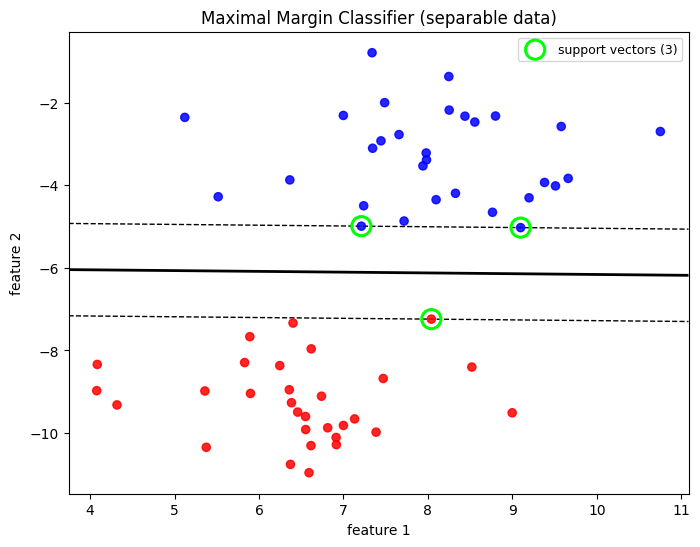

training accuracy : 1.000
support vectors   : 3 out of 60 points
margin width      : 2.236


In [8]:
X_sep, y_sep = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.1)

hard = SVC(kernel='linear', C=1e6).fit(X_sep, y_sep)   # huge C = almost no tolerance
margin = 2 / np.linalg.norm(hard.coef_[0])

plt.figure(figsize=(8, 6))
plot_svm(hard, X_sep, y_sep, title='Maximal Margin Classifier (separable data)')
plt.xlabel('feature 1'); plt.ylabel('feature 2')
plt.show()

print('training accuracy : %.3f' % hard.score(X_sep, y_sep))
print('support vectors   : %d out of %d points' % (len(hard.support_), len(X_sep)))
print('margin width      : %.3f' % margin)

**Read the picture.** The solid line is the boundary; the two dashed lines are the edges
of the margin. Three points sit exactly on the dashed lines and are circled - those are the
**support vectors**.

**Only 3 points out of 60 define this model.** Delete any of the other 57 and refit: you get
the identical line. Move one support vector and the line moves. This is what "support" means
- the boundary is resting on them.

That is very different from logistic regression, where every observation contributes to the
likelihood and therefore tugs on the fit. It has two practical consequences:

* **Efficient.** The model stores only the support vectors, not the training set.
* **Sensitive.** A single mislabelled point placed on the margin can move the boundary a long
  way. Which is the problem slide 99 solves.

## 1.2 The Support Vector Classifier: the soft margin and `C`

Real data is not separable. One borrower with an excellent profile defaults; one apparent
disaster repays in full. Slide 99 introduces the **soft margin**, which lets some points sit
inside the margin - or on the wrong side of it - in exchange for a wider, more stable
boundary.

`C` is the price of a violation:

* **Large C** - violations are expensive. Narrow margin, few support vectors, boundary
  contorts to fit awkward points. **Low bias, high variance.**
* **Small C** - violations are cheap. Wide margin, many support vectors, boundary ignores
  individual awkward points. **High bias, low variance.**

Watch what one badly-placed borrower does.

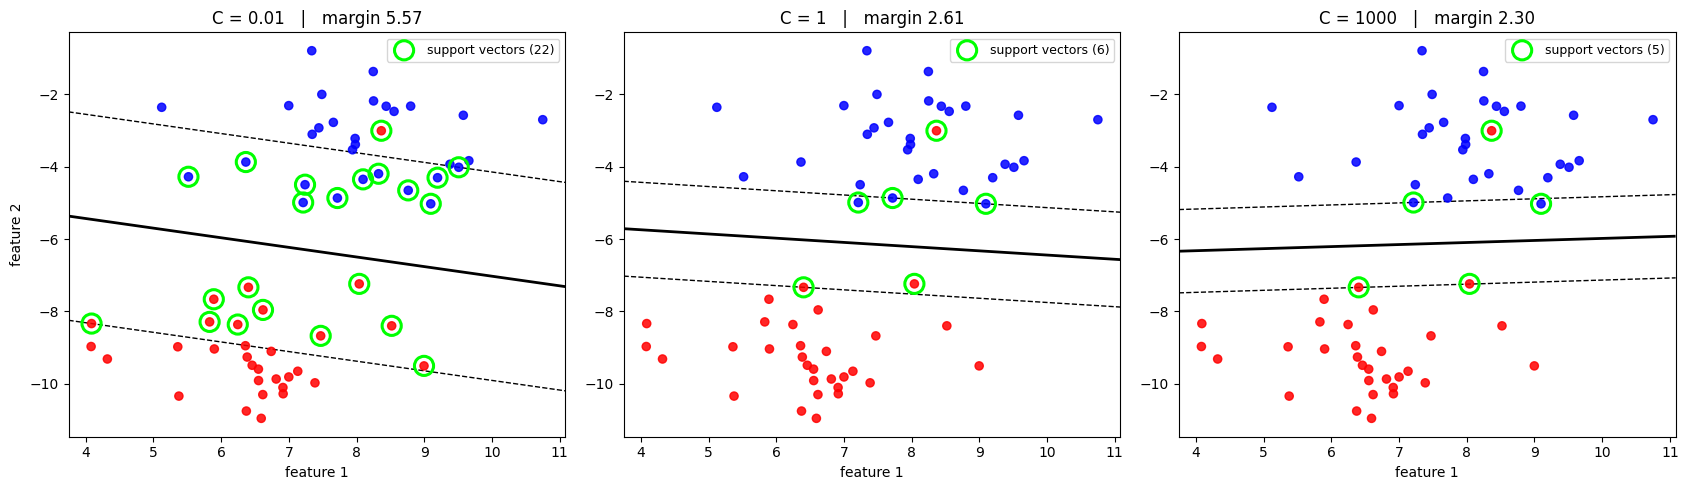

In [9]:
# take the separable data and drop ONE class-1 customer into the middle of class 0
X_awk = np.vstack([X_sep, X_sep[y_sep == 0].mean(axis=0) + [0.3, 0.3]])
y_awk = np.append(y_sep, 1)

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, C in zip(ax, [0.01, 1, 1000]):
    m = SVC(kernel='linear', C=C).fit(X_awk, y_awk)
    plot_svm(m, X_awk, y_awk, ax=a,
             title='C = %g   |   margin %.2f' % (C, 2 / np.linalg.norm(m.coef_[0])))
    a.set_xlabel('feature 1')
ax[0].set_ylabel('feature 2')
plt.tight_layout()
plt.show()

In [10]:
print(' %8s %8s %10s %12s %14s' % ('C', '#SV', 'margin', 'train acc', 'misclassified'))
for C in [0.01, 0.05, 0.1, 1, 10, 1000]:
    m = SVC(kernel='linear', C=C).fit(X_awk, y_awk)
    print(' %8g %8d %10.3f %12.3f %14d'
          % (C, len(m.support_), 2 / np.linalg.norm(m.coef_[0]),
             m.score(X_awk, y_awk), int((m.predict(X_awk) != y_awk).sum())))

print()
print('For comparison, the SAME data without that one awkward customer, hard margin:')
print('  %d support vectors, margin %.3f, accuracy %.3f'
      % (len(hard.support_), margin, hard.score(X_sep, y_sep)))

        C      #SV     margin    train acc  misclassified
     0.01       22      5.573        0.984              1
     0.05       12      3.744        0.984              1
      0.1        8      3.302        0.984              1
        1        6      2.607        0.984              1
       10        5      2.295        0.984              1
     1000        5      2.302        0.984              1

For comparison, the SAME data without that one awkward customer, hard margin:
  3 support vectors, margin 2.236, accuracy 1.000


**Conclusion.** Follow the margin column: **5.573** at `C = 0.01` down to **2.302** at
`C = 1000`. Small `C` buys a margin more than twice as wide, and pays for it with support
vectors - **22** instead of **5**.

Notice what does *not* change: every model misclassifies exactly **one** point, the awkward
customer, and all of them score 0.984. **`C` is not choosing how many mistakes to make on
the training set here - it is choosing how much of the data the boundary is allowed to lean
on.** The wide-margin model rests on 22 customers, so no single one of them can move it far.
The narrow-margin model rests on 5.

That is the bias-variance trade-off in a form you can see. And as in Week 2 with `k`, whether
it changes *test* accuracy depends on the data - on well-behaved data it often does not.
Tune `C` by cross-validation; do not assume a large one is "more accurate".

## 1.3 The Kernel Trick

Now the fraud-ring geometry from Week 2, where a straight line is hopeless. Slide 104 says
SVMs handle this by *enlarging the feature space*. Slides 105-106 give the two kernels:

* **Polynomial:** $K(x, x') = (1 + \langle x, x' \rangle)^d$
* **RBF (radial basis function):** $K(x, x') = \exp(-\gamma \|x - x'\|^2)$

The trick is that you never actually build the enlarged features. The optimisation only ever
needs **inner products between pairs of observations** (slides 96 and 100), and a kernel
computes the inner product *in the enlarged space* directly from the original coordinates.
An RBF kernel corresponds to an infinite-dimensional space, and it still costs one
exponential per pair.

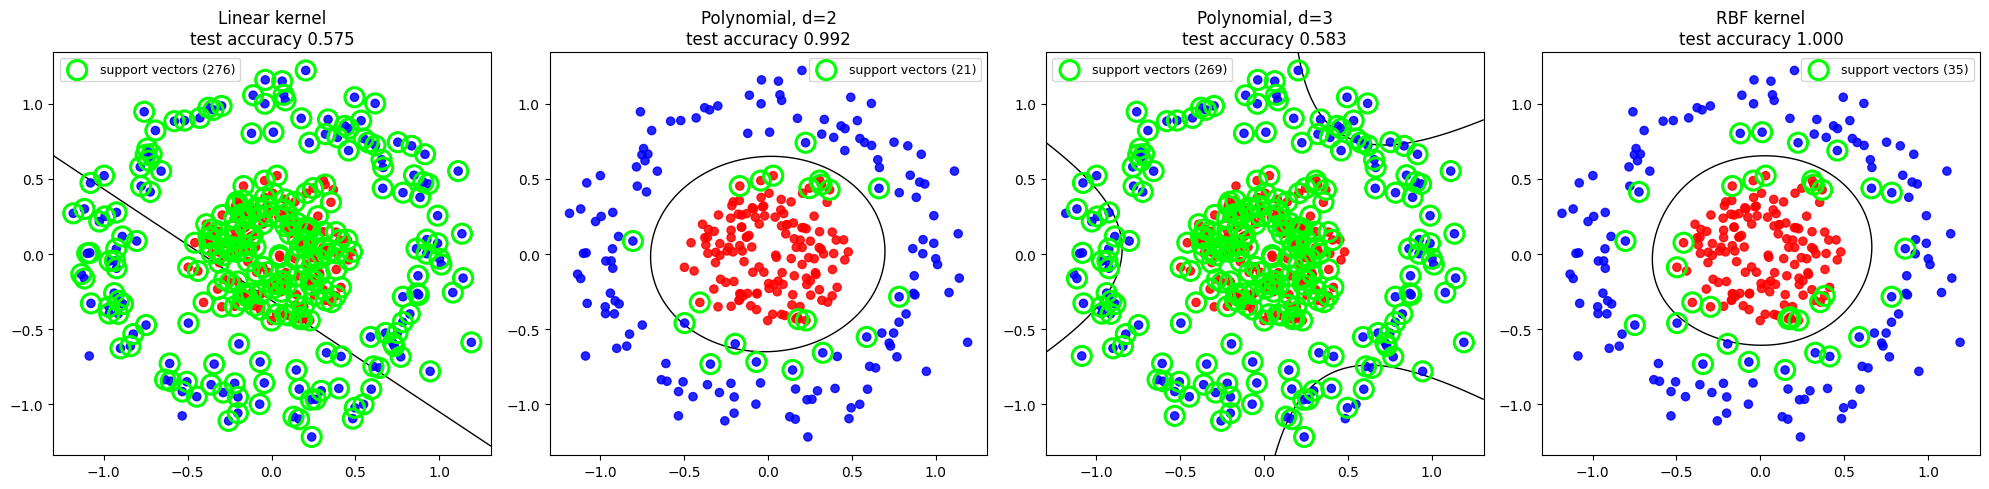

                           train       test
 Linear kernel             0.643      0.575
 Polynomial, d=2           0.993      0.992
 Polynomial, d=3           0.629      0.583
 RBF kernel                1.000      1.000
 Logistic regression       0.525      0.483


In [11]:
X_ring, y_ring = make_circles(n_samples=400, factor=.3, noise=.12, random_state=100)
Rtr, Rte, gtr, gte = train_test_split(X_ring, y_ring, test_size=0.3,
                                      random_state=42, stratify=y_ring)

models = [('Linear kernel',     SVC(kernel='linear')),
          ('Polynomial, d=2',   SVC(kernel='poly', degree=2)),
          ('Polynomial, d=3',   SVC(kernel='poly', degree=3)),
          ('RBF kernel',        SVC(kernel='rbf'))]

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, (name, m) in zip(ax, models):
    m.fit(Rtr, gtr)
    plot_svm(m, Rtr, gtr, ax=a, show_margin=False,
             title='%s\ntest accuracy %.3f' % (name, m.score(Rte, gte)))
plt.tight_layout()
plt.show()

print(' %-20s %10s %10s' % ('', 'train', 'test'))
for name, m in models:
    print(' %-20s %10.3f %10.3f' % (name, m.score(Rtr, gtr), m.score(Rte, gte)))
lr = LogisticRegression().fit(Rtr, gtr)
print(' %-20s %10.3f %10.3f' % ('Logistic regression', lr.score(Rtr, gtr), lr.score(Rte, gte)))

**Conclusion.** The numbers are stark:

| model | test accuracy |
|---|---|
| Logistic regression | **0.483** |
| SVM, linear kernel | **0.575** |
| SVM, polynomial d=3 | **0.583** |
| SVM, polynomial d=2 | **0.992** |
| SVM, RBF | **1.000** |

Logistic regression scores **below a coin toss**. So does a linear SVM - the kernel is what
matters here, not the algorithm.

**Why does d=2 succeed and d=3 fail?** Because the true boundary *is* a circle,
$x_1^2 + x_2^2 = r^2$, which is exactly a degree-2 polynomial. A degree-3 kernel spans the
wrong function class for this geometry and does no better than a line. This is the honest
lesson about kernels: they are an assumption about the *shape* of the boundary, and a wrong
assumption costs you everything.

**The RBF kernel scores 1.000 without being told the shape.** It measures how close two
points are and makes the boundary follow local density, so it adapts to whatever geometry
is there. That generality is why it is the default in `sklearn` and the right first choice
when you have no strong prior - which, in finance, is usually.

## 1.4 `gamma`: the dial that overfits

The RBF kernel above used `sklearn`'s default `gamma`. It is worth seeing what the parameter
does, because it is the fastest way to overfit an SVM.

$\gamma$ controls how far the influence of a single training point reaches. Small
$\gamma$ = wide influence = smooth boundary. Large $\gamma$ = each point only affects its
immediate neighbourhood = the boundary wraps individual observations.

      gamma      #SV      train       test        gap
       0.01      280      0.711      0.658      0.052
        0.1      241      0.968      0.975     -0.007
          1       38      1.000      1.000      0.000
         10       51      1.000      1.000      0.000
        100      215      1.000      0.975      0.025
       1000      275      1.000      0.892      0.108


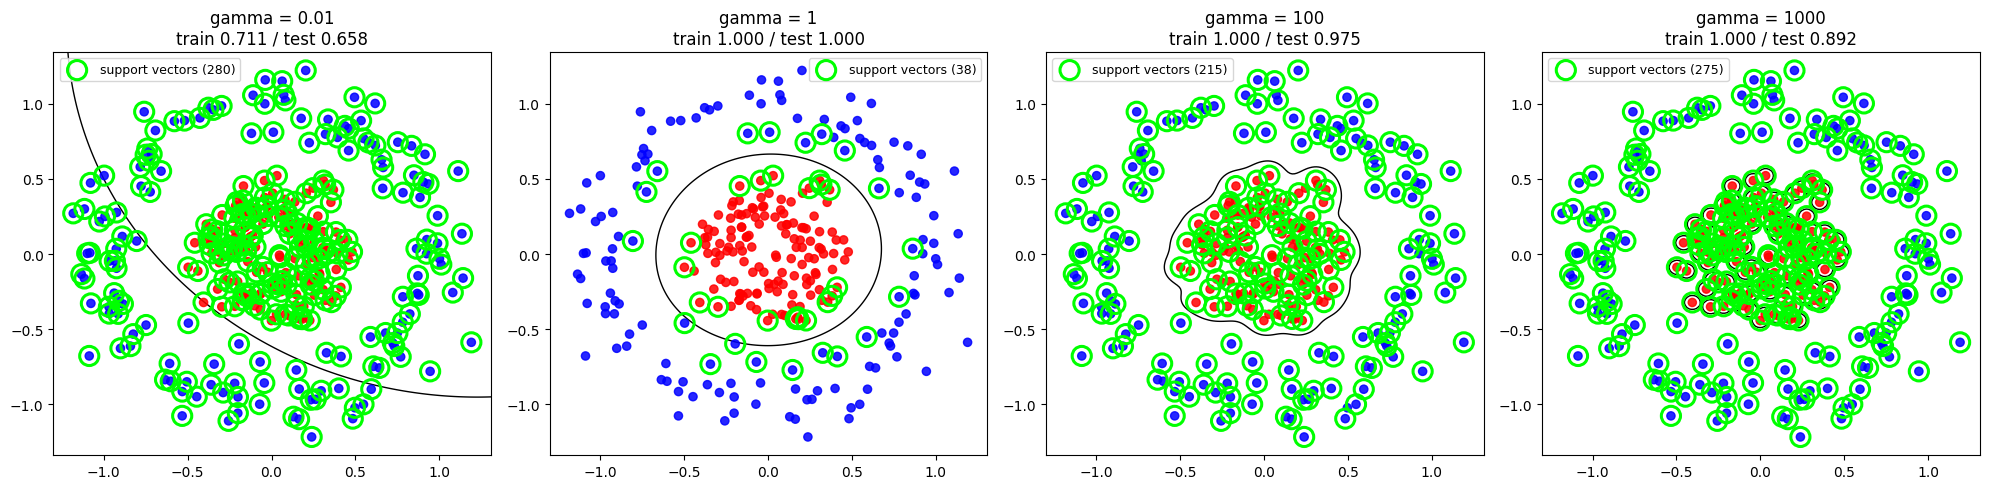

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, g in zip(ax, [0.01, 1, 100, 1000]):
    m = SVC(kernel='rbf', gamma=g).fit(Rtr, gtr)
    plot_svm(m, Rtr, gtr, ax=a, show_margin=False,
             title='gamma = %g\ntrain %.3f / test %.3f' % (g, m.score(Rtr, gtr), m.score(Rte, gte)))
plt.tight_layout()
plt.show()

print(' %10s %8s %10s %10s %10s' % ('gamma', '#SV', 'train', 'test', 'gap'))
for g in [0.01, 0.1, 1, 10, 100, 1000]:
    m = SVC(kernel='rbf', gamma=g).fit(Rtr, gtr)
    tr, te = m.score(Rtr, gtr), m.score(Rte, gte)
    print(' %10g %8d %10.3f %10.3f %10.3f' % (g, len(m.support_), tr, te, tr - te))

**Conclusion.** This is the cleanest bias-variance picture in the course.

* **gamma = 0.01:** train 0.711, test 0.658. Influence is so wide the boundary is nearly
  straight - it cannot represent the rings. **Underfitting.**
* **gamma = 1:** train 1.000, test 1.000, and only **38** support vectors. The sweet spot.
* **gamma = 1000:** train **1.000**, test **0.892**, and **275** support vectors - 98% of the
  training set. The model has memorised individual points; the last panel shows islands drawn
  around them.

**The support-vector count is your warning light.** When the number of support vectors
approaches the size of the training set, the model has stopped generalising and started
remembering. You can read that off the fitted model without a test set, which is useful.

In practice, tune `C` and `gamma` **together** with `GridSearchCV` - they interact, and the
best `gamma` depends on the `C` you pair it with.

## 1.5 SVMs must be scaled (the Week 2 lesson, again)

The RBF kernel is $\exp(-\gamma\|x - x'\|^2)$. That $\|x - x'\|^2$ is the same squared
Euclidean distance that destroyed KNN in Week 2 when one feature was measured in euros and
the other in something smaller.

Same credit book as Week 2: `annual_income` with a spread of about 13,300 and `card_balance`
with about 480.

In [ ]:
Xb, yb = make_blobs(n_samples=600, centers=2, random_state=100, cluster_std=7)
credit = pd.DataFrame({'annual_income': (Xb[:, 0] * 1825 + 52000).round(0),
                       'card_balance':  (Xb[:, 1] * 52   + 1800).round(0)})

Ctr, Cte, ctr, cte = train_test_split(credit, yb, test_size=0.3,
                                      random_state=42, stratify=yb)

svm_raw = SVC(kernel='rbf').fit(Ctr, ctr)
svm_scaled = make_pipeline(StandardScaler(), SVC(kernel='rbf')).fit(Ctr, ctr)

print('SVM (RBF) on RAW euros : accuracy %.3f   support vectors %d of %d  (%.0f%%)'
      % (svm_raw.score(Cte, cte), len(svm_raw.support_), len(Ctr),
         100 * len(svm_raw.support_) / len(Ctr)))
print('SVM (RBF) with a Scaler: accuracy %.3f   support vectors %d of %d  (%.0f%%)'
      % (svm_scaled.score(Cte, cte), len(svm_scaled[-1].support_), len(Ctr),
         100 * len(svm_scaled[-1].support_) / len(Ctr)))

SVM (RBF) on RAW euros : accuracy 0.594   support vectors 376 of 420  (90%)
SVM (RBF) with a Scaler: accuracy 0.744   support vectors 203 of 420  (48%)


**Conclusion.** Accuracy falls from **0.744** to **0.594** without the scaler - but look
at the second number, because it is the one that tells you *why*.

The unscaled model keeps **376 of 420** training points as support vectors - **90%** of the
data. The scaled model keeps **203**. An SVM that needs almost every observation to define
its boundary has not found a boundary; it is storing the training set. The `income` term
dominates the distance so completely that every point looks equally far from every other, and
the kernel can no longer tell neighbours from strangers.

**The diagnostic worth remembering: if your SVM retains most of the training set as support
vectors, check your feature scales before you touch `C` or `gamma`.**

Always: `make_pipeline(StandardScaler(), SVC(...))`.

---
# Part 2: K-Means Clustering

Everything so far this course has been **supervised**: we had a `y`. From here we do not.

We have customers and no column telling us what type each one is. There is no accuracy to
compute, because there is nothing to be right about. The question changes from *"is this
prediction correct?"* to *"is this grouping useful?"*, and that is a much softer question -
which is exactly why the rest of this notebook spends so much effort on how to judge a
clustering.

## 2.1 The data

Two features per customer: annual income and a spending score. We suspect there are distinct
customer types but no column says so.

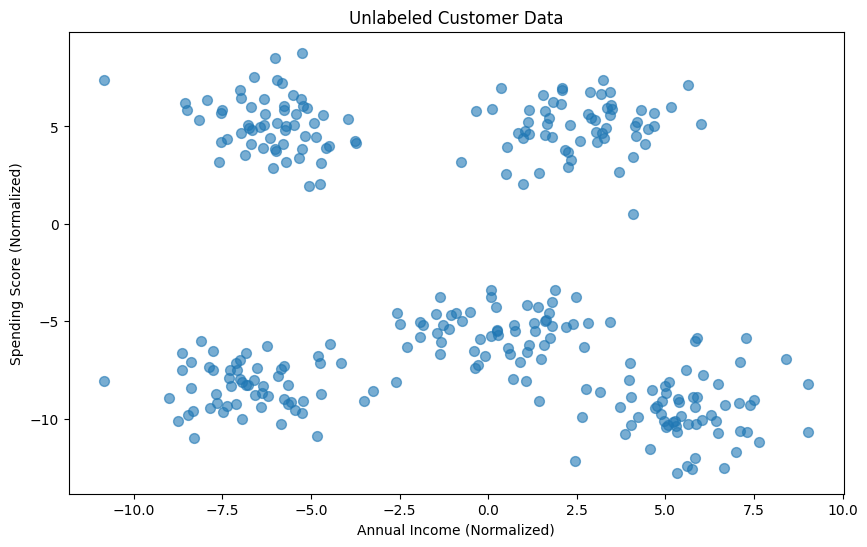

We generated this with 5 groups, so we know the answer - which is the only reason
we can grade the algorithm later. On real data you never get to do this.


In [13]:
X, y_true = make_blobs(n_samples=300, centers=5, cluster_std=1.5, random_state=10)

plt.figure(figsize=[10, 6])
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6)
plt.title("Unlabeled Customer Data")
plt.xlabel("Annual Income (Normalized)")
plt.ylabel("Spending Score (Normalized)")
plt.show()

print('We generated this with 5 groups, so we know the answer - which is the only reason')
print('we can grade the algorithm later. On real data you never get to do this.')

## 2.2 Inside the algorithm

K-Means is iterative. From slide 115:

1. **Specify K:** choose the number of clusters.
2. **Initialize:** pick K points as the starting centroids.
3. **Assign:** every point joins the nearest centroid.
4. **Update:** each centroid moves to the mean of its members.
5. **Repeat** 3 and 4 until nothing moves.

Let us watch it run. Note we deliberately ask for **K=4** on data that has 5 groups, so you
can see what a wrong K looks like from the inside.

converged after 16 iterations


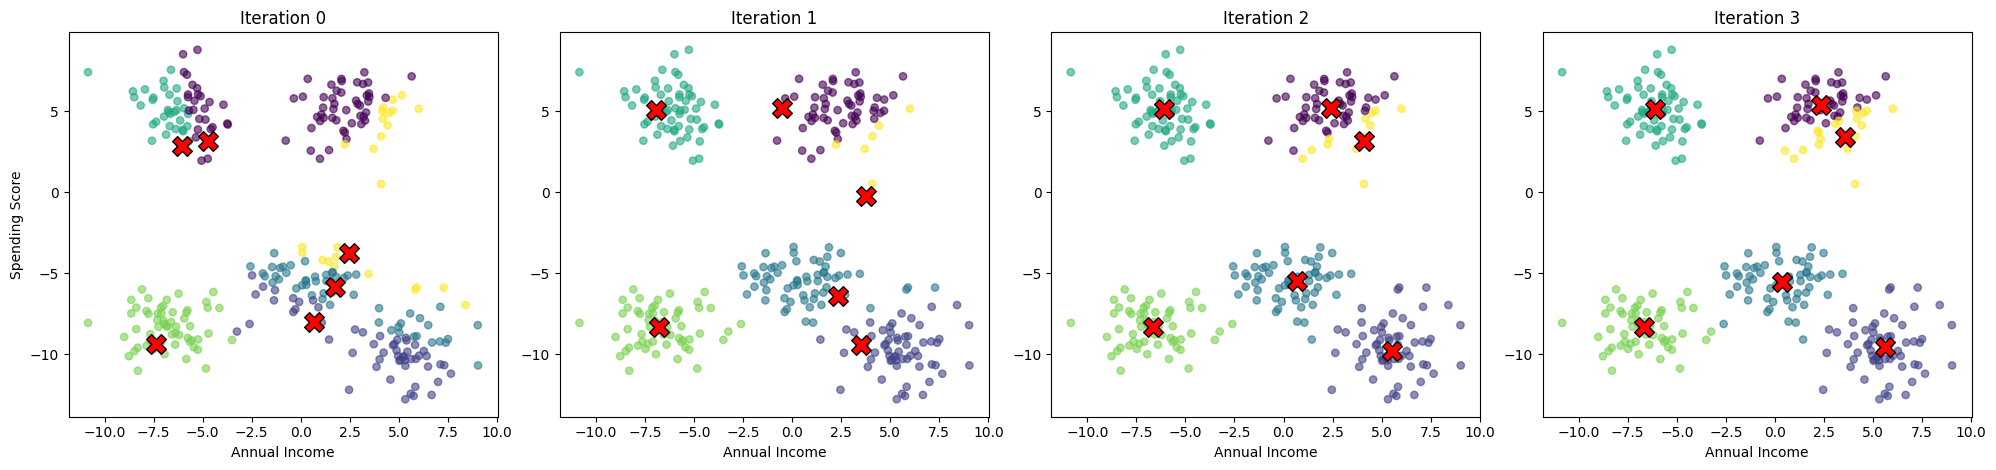

In [16]:
def find_clusters_step_by_step(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    history = []
    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)
        history.append((centers.copy(), labels.copy()))

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])

        if np.all(centers == new_centers):     # converged
            break
        centers = new_centers

    return history

history = find_clusters_step_by_step(X, 6)
print('converged after %d iterations' % len(history))

fig, ax = plt.subplots(1, 4, figsize=(20, 4.8))
for a, (centers, labels) in zip(ax, history[:4]):
    a.scatter(X[:, 0], X[:, 1], c=labels, s=28, cmap='viridis', alpha=0.6)
    a.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X',
              edgecolors='black', zorder=5)
    a.set_xlabel("Annual Income")
for i, a in enumerate(ax):
    a.set_title("Iteration %d" % i)
ax[0].set_ylabel("Spending Score")
plt.tight_layout()
plt.show()

**What to notice.** The centroids move a long way on the first update and barely at all
by the fourth - K-Means converges fast. It is also **guaranteed to converge**, because every
step can only decrease the within-cluster sum of squares, and that quantity is bounded below.

But it converges to a **local** minimum, not the best one. Two things follow, both on
slide 127:

* **The starting positions matter.** Change `rseed` and you can land somewhere else.
  `sklearn` defends against this with `n_init=10` (run it ten times from different starts,
  keep the best) and `init='k-means++'` (spread the initial centroids out rather than picking
  at random). Use both. They are the defaults for good reason.
* **You had to choose K in advance.** The algorithm cannot tell you that 4 was wrong. That
  is Part 3.

---
# Part 3: Choosing K

## 3.1 The Elbow Method

From slide 122, K-Means minimises the **Within-Cluster Sum of Squares** (WCSS, also called
**inertia**): the total squared distance from each point to its own centroid.

WCSS always falls as K rises - at K = n it reaches zero, with every point its own cluster.
So we cannot just minimise it. We look for the **elbow**: where the improvement stops being
worth the extra cluster.

   K         WCSS    improvement
   1      20718.4               
   2       8541.1            59%
   3       4699.9            45%
   4       2427.3            48%
   5       1163.5            52%
   6       1067.2             8%
   7        974.5             9%
   8        885.3             9%
   9        790.6            11%
  10        735.7             7%


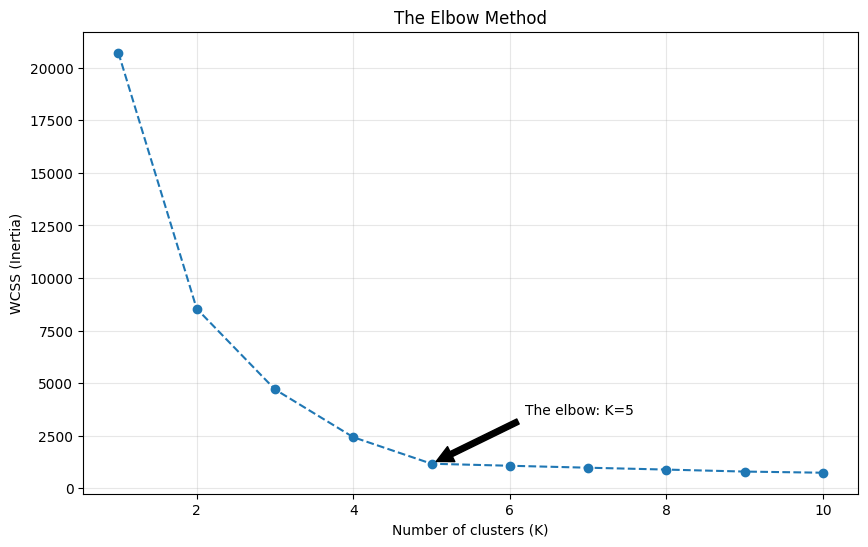

In [17]:
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X)
    wcss.append(km.inertia_)

print(' %3s %12s %14s' % ('K', 'WCSS', 'improvement'))
for i, (k, v) in enumerate(zip(k_range, wcss)):
    imp = '' if i == 0 else '%12.0f%%' % (100 * (wcss[i - 1] - v) / wcss[i - 1])
    print(' %3d %12.1f %14s' % (k, v, imp))

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.annotate('The elbow: K=5', xy=(5, wcss[4]), xytext=(6.2, wcss[4] * 3),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(alpha=0.3)
plt.show()

**Conclusion.** The improvement column makes the elbow unambiguous. Each cluster up to
the fifth removes **45-59%** of the remaining WCSS. The sixth removes **8%**, and every one
after that is in the same range.

So K=5 is the last cluster that pays for itself, and the curve visibly flattens straight
after it. That matches the 5 groups we generated.

**Be honest about the method, though: the elbow is read by eye and it is often ambiguous.**
On real data the bend is rarely this clean. That is why we cross-check with a number.

## 3.2 The Silhouette Score

From slide 125. For each point $i$:

* $a_i$ = average distance to the other points in **its own** cluster
* $b_i$ = average distance to the points of the **nearest other** cluster

$$ s_i = \frac{b_i - a_i}{\max(a_i, b_i)} $$

* $s_i \approx 1$: comfortably inside its cluster
* $s_i \approx 0$: sitting on the border between two clusters
* $s_i < 0$: closer to another cluster than its own - probably mislabelled

The overall score is the average over all points. Unlike WCSS it does **not** automatically
improve with K, so it can be maximised directly.

  K=2   silhouette 0.5546
  K=3   silhouette 0.5577
  K=4   silhouette 0.6178
  K=5   silhouette 0.6614   <- best
  K=6   silhouette 0.5920
  K=7   silhouette 0.5121
  K=8   silhouette 0.4618
  K=9   silhouette 0.3974
  K=10  silhouette 0.3936


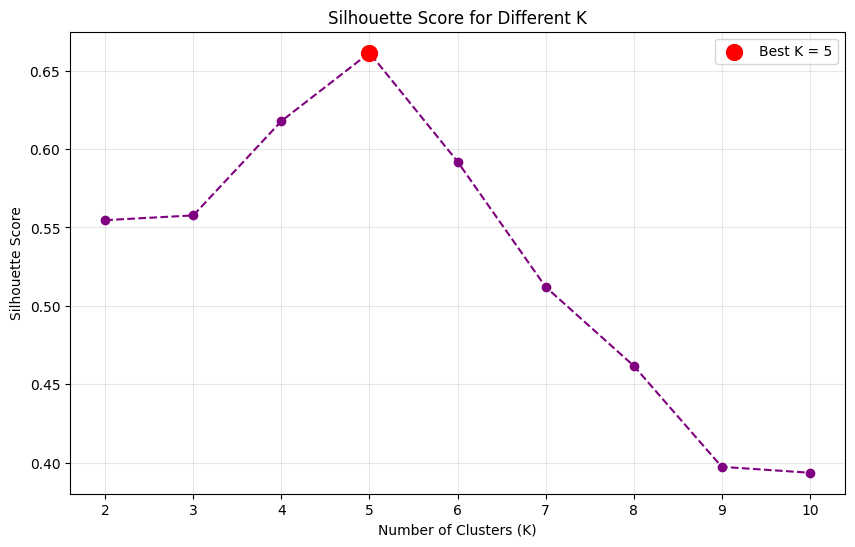

In [ ]:
sil = []
sil_range = range(2, 11)      # silhouette is undefined for K=1
for k in sil_range:
    labels = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit_predict(X)
    sil.append(silhouette_score(X, labels))

best_k = list(sil_range)[int(np.argmax(sil))]
for k, s in zip(sil_range, sil):
    print('  K=%-3d silhouette %.4f%s' % (k, s, '   <- best' if k == best_k else ''))

plt.figure(figsize=(10, 6))
plt.plot(list(sil_range), sil, marker='o', linestyle='--', color='purple')
plt.scatter([best_k], [max(sil)], color='red', s=130, zorder=5, label='Best K = %d' % best_k)
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Silhouette Score')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Adjusted Rand Index against the true groups: 0.975
(1.0 = perfect, 0.0 = no better than random. You can only compute this
 because the data is synthetic - it is a check on the method, not a real metric.)


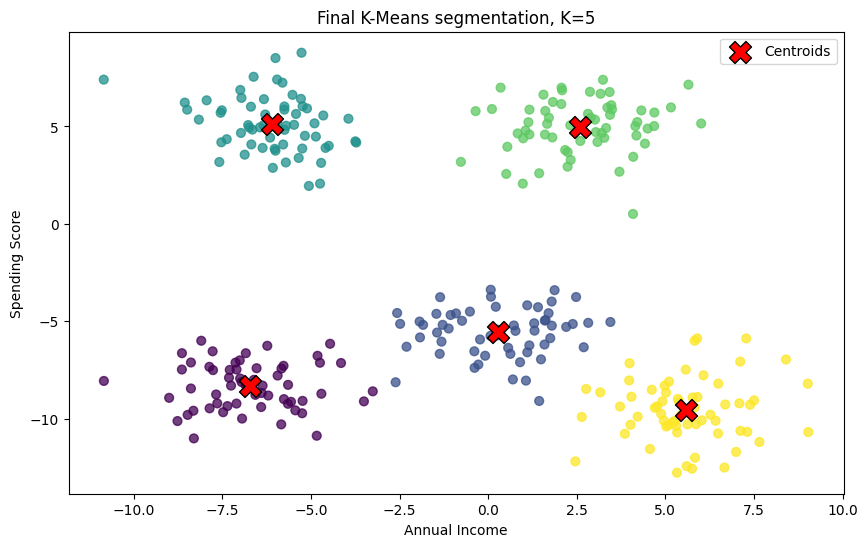

In [18]:
# We generated this data, so for once we can actually grade the clustering.
final = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels_final = final.fit_predict(X)
print('Adjusted Rand Index against the true groups: %.3f'
      % adjusted_rand_score(y_true, labels_final))
print('(1.0 = perfect, 0.0 = no better than random. You can only compute this')
print(' because the data is synthetic - it is a check on the method, not a real metric.)')

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_final, s=40, cmap='viridis', alpha=0.75)
plt.scatter(final.cluster_centers_[:, 0], final.cluster_centers_[:, 1],
            c='red', s=250, marker='X', edgecolors='black', label='Centroids')
plt.title('Final K-Means segmentation, K=5')
plt.xlabel('Annual Income'); plt.ylabel('Spending Score')
plt.legend(); plt.show()

**Conclusion.** The silhouette peaks at **K=5** with **0.661**, agreeing with the elbow.
When two independent criteria agree you can be reasonably confident; when they disagree, that
disagreement is information - it usually means the cluster structure is weak.

The ARI of **0.975** confirms the recovered groups are almost exactly the ones we generated.

**Two warnings before you trust any of this.**

1. **A silhouette score is always computable, even on structureless data.** Run K-Means on
   pure noise and it will happily return 5 clusters with a positive silhouette. The score
   ranks candidate Ks; it does not tell you clusters exist.
2. **The number is not the decision.** If K=5 and K=6 score 0.661 and 0.659, pick the one
   whose segments the marketing team can actually name and act on.

---
# Part 4: What K-Means Assumes

## 4.1 It assumes you scaled the features

K-Means minimises squared **distance**, so it inherits the Week 2 problem exactly. Here is
the same segmentation task in real units - income in euros, spending score on a 1-100 scale.
**This is the situation in your homework.**

In [ ]:
Xs, ys = make_blobs(n_samples=400, centers=4, cluster_std=1.1, random_state=5)
seg = pd.DataFrame({'annual_income_eur': (Xs[:, 0] * 4200 + 55000).round(0),
                    'spending_score':    (Xs[:, 1] * 3.9 + 55).round(1)})

ratio = seg.annual_income_eur.std() / seg.spending_score.std()
print(seg.describe().round(1).to_string())
print()
print('income spread / spending spread = %.0fx' % ratio)

raw_labels = KMeans(4, init='k-means++', n_init=10, random_state=42).fit_predict(seg)
scaled_labels = KMeans(4, init='k-means++', n_init=10,
                       random_state=42).fit_predict(StandardScaler().fit_transform(seg))

print()
print('ARI against the true segments, RAW    : %.3f' % adjusted_rand_score(ys, raw_labels))
print('ARI against the true segments, SCALED : %.3f' % adjusted_rand_score(ys, scaled_labels))

       annual_income_eur  spending_score
count              400.0           400.0
mean             48309.6            73.0
std              19829.7            14.1
min              15193.0            43.3
25%              30277.2            59.3
50%              42199.5            73.7
75%              63643.2            86.0
max              87994.0            99.0

income spread / spending spread = 1404x

ARI against the true segments, RAW    : 0.644
ARI against the true segments, SCALED : 0.705


In [ ]:
# The ARI gap is modest. The SEGMENTS are not. Describe them the way marketing would.
print('Clusters found on RAW euros:')
for c in sorted(set(raw_labels)):
    m = seg[raw_labels == c]
    print('  cluster %d  income %6.0f - %6.0f   spending %4.1f - %4.1f   n=%d'
          % (c, m.annual_income_eur.min(), m.annual_income_eur.max(),
             m.spending_score.min(), m.spending_score.max(), len(m)))

print()
print('Clusters found on SCALED features:')
for c in sorted(set(scaled_labels)):
    m = seg[scaled_labels == c]
    print('  cluster %d  income %6.0f - %6.0f   spending %4.1f - %4.1f   n=%d'
          % (c, m.annual_income_eur.min(), m.annual_income_eur.max(),
             m.spending_score.min(), m.spending_score.max(), len(m)))

Clusters found on RAW euros:
  cluster 0  income  15193 -  31406   spending 73.7 - 99.0   n=113
  cluster 1  income  67036 -  87994   spending 43.3 - 69.2   n=99
  cluster 2  income  45997 -  65417   spending 54.0 - 73.7   n=98
  cluster 3  income  31619 -  44751   spending 59.3 - 98.8   n=90

Clusters found on SCALED features:
  cluster 0  income  15193 -  41965   spending 73.7 - 87.7   n=120
  cluster 1  income  65417 -  87994   spending 43.3 - 69.2   n=100
  cluster 2  income  42434 -  63052   spending 54.0 - 73.7   n=100
  cluster 3  income  17546 -  41149   spending 86.6 - 99.0   n=80


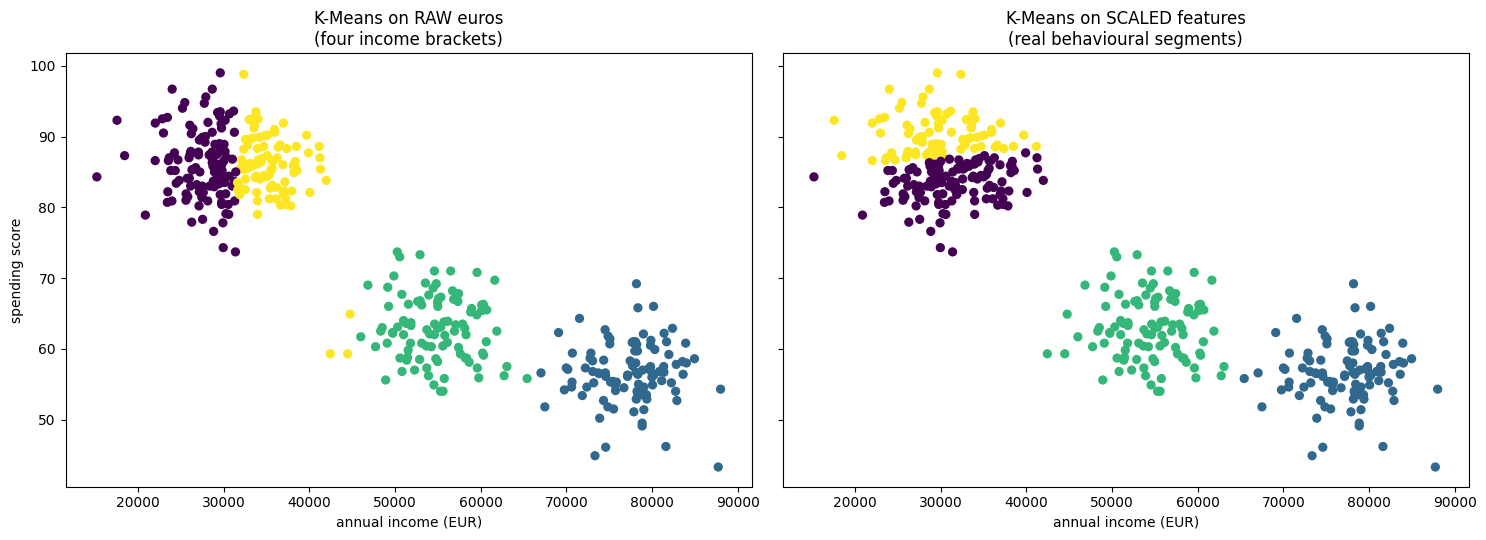

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
ax[0].scatter(seg.annual_income_eur, seg.spending_score, c=raw_labels, cmap='viridis', s=32)
ax[0].set_title('K-Means on RAW euros\n(four income brackets)')
ax[1].scatter(seg.annual_income_eur, seg.spending_score, c=scaled_labels, cmap='viridis', s=32)
ax[1].set_title('K-Means on SCALED features\n(real behavioural segments)')
for a in ax:
    a.set_xlabel('annual income (EUR)')
ax[0].set_ylabel('spending score')
plt.tight_layout(); plt.show()

**Conclusion, and read the cluster tables rather than the ARI.**

The ARI only moves from **0.644** to **0.705**, which understates the problem badly. Look at
what the raw clustering actually produced: four clusters whose income ranges are
**15k-31k, 31k-44k, 45k-65k, 67k-88k** - perfectly ordered, non-overlapping bands - while
their spending ranges overlap almost completely.

**The unscaled model has rediscovered income quartiles.** It never looked at spending score
at all, because with a **1,404x** spread ratio the spending column contributes essentially
nothing to the distance. You could have produced that segmentation with `pd.qcut` and no
machine learning.

That is the business failure. A marketing team handed "four income brackets" learns nothing
it did not already know. The scaled version finds groups that differ in *behaviour* - the
high-income low-spenders, the low-income high-spenders - which is the entire point of
segmenting customers.

**Always `StandardScaler` before K-Means.** In your homework the two features are income in
thousands of dollars and a 1-100 score; skip the scaler and you will hand in income brackets.

## 4.2 It assumes clusters are round, similar-sized, and separated by gaps

Slide 127 lists the failure modes. The one worth seeing is shape: K-Means partitions space
into **Voronoi cells** around centroids, and a Voronoi cell is always convex. If the true
clusters are not convex, no choice of K can help.

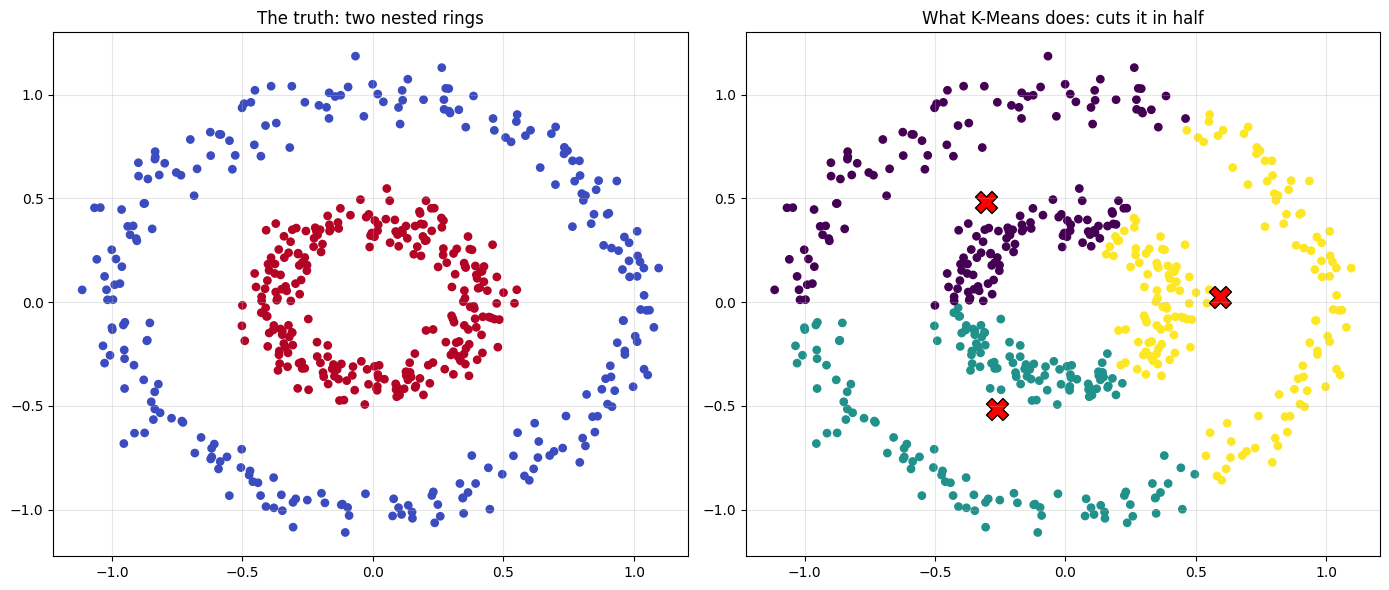

Adjusted Rand Index vs the true rings: -0.003
(0.0 means the clustering carries no information about the true groups at all.)


In [20]:
X_rings, y_rings = make_circles(n_samples=500, factor=0.4, noise=0.06, random_state=42)

km_rings = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_rings = km_rings.fit_predict(X_rings)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].scatter(X_rings[:, 0], X_rings[:, 1], c=y_rings, cmap='coolwarm', s=28)
ax[0].set_title('The truth: two nested rings')
ax[1].scatter(X_rings[:, 0], X_rings[:, 1], c=labels_rings, cmap='viridis', s=28)
ax[1].scatter(km_rings.cluster_centers_[:, 0], km_rings.cluster_centers_[:, 1],
              c='red', s=250, marker='X', edgecolors='black')
ax[1].set_title('What K-Means does: cuts it in half')
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Adjusted Rand Index vs the true rings: %.3f' % adjusted_rand_score(y_rings, labels_rings))
print('(0.0 means the clustering carries no information about the true groups at all.)')

**Conclusion.** The ARI is **-0.002** - indistinguishable from random labelling.

K-Means did not do a mediocre job here; it did a **completely uninformative** one, and it
reported no distress while doing it. Its inertia converged, the algorithm terminated
normally, and the silhouette score is positive. Nothing in the output says "this model is
meaningless".

Both centroids sit near the origin, so the only way to assign points to the nearer one is to
cut the plane roughly in half. The rings share a centre, and a method that describes clusters
by their centre cannot separate them, ever.

We need a method that defines a cluster by **density** rather than by distance to a centre.

---
# Part 5: DBSCAN

From slides 131-132. DBSCAN takes two parameters:

* **eps** ($\epsilon$): the radius of a neighbourhood.
* **min_samples** (MinPts): how many points must be inside that radius for a point to be
  **core**.

Every point is then one of three things:

* **Core point:** at least `min_samples` points within `eps` (counting itself).
* **Border point:** not core, but within `eps` of a core point.
* **Noise:** neither. DBSCAN is the first method we have met that is allowed to say
  *"this observation belongs to nothing"*.

It needs no K, and it makes no assumption about shape.

DBSCAN found 2 clusters and 1 noise points
Adjusted Rand Index vs the true rings: 0.996

K-Means on the identical data scored -0.003.


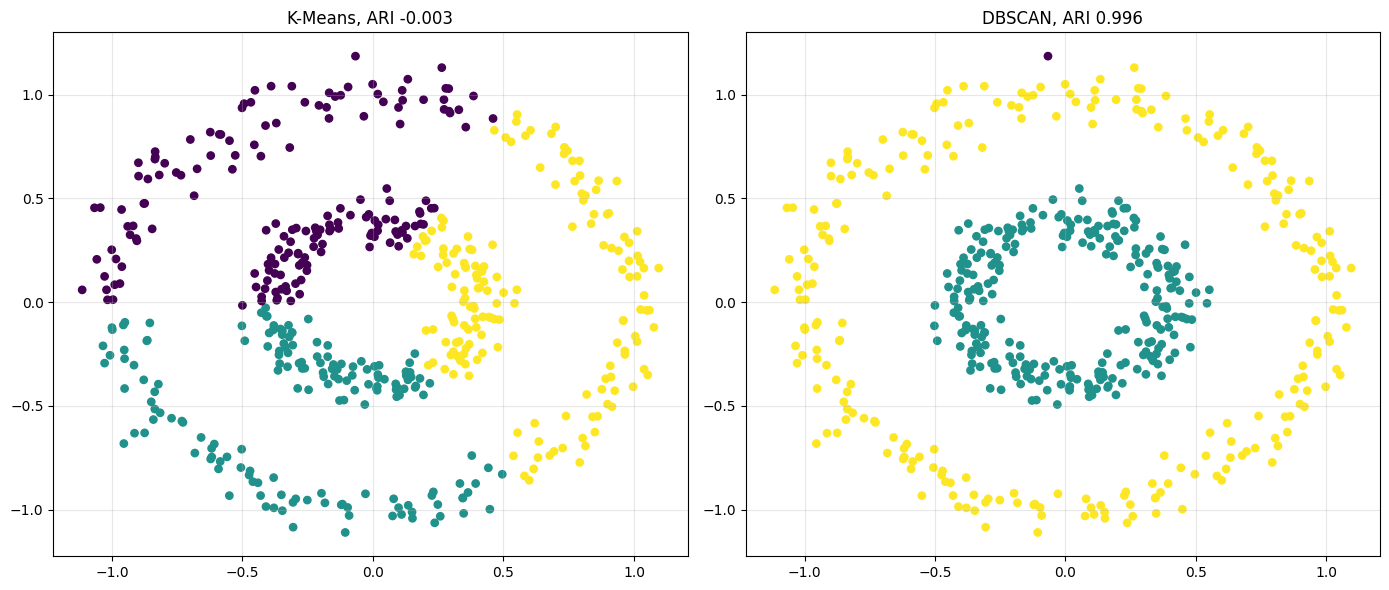

In [25]:
db = DBSCAN(eps=0.14, min_samples=5)
labels_db = db.fit_predict(X_rings)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int((labels_db == -1).sum())
print('DBSCAN found %d clusters and %d noise points' % (n_clusters, n_noise))
print('Adjusted Rand Index vs the true rings: %.3f' % adjusted_rand_score(y_rings, labels_db))
print()
print('K-Means on the identical data scored %.3f.' % adjusted_rand_score(y_rings, labels_rings))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].scatter(X_rings[:, 0], X_rings[:, 1], c=labels_rings, cmap='viridis', s=28)
ax[0].set_title('K-Means, ARI %.3f' % adjusted_rand_score(y_rings, labels_rings))
ax[1].scatter(X_rings[:, 0], X_rings[:, 1], c=labels_db, cmap='viridis', s=28)
ax[1].set_title('DBSCAN, ARI %.3f' % adjusted_rand_score(y_rings, labels_db))
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusion.** DBSCAN recovers the two rings **exactly** - ARI **1.000** against K-Means'
**-0.002** on identical data.

The reason is that DBSCAN never asks "which centre is this point near?". It asks "can I walk
from this point to that one in small steps, always staying in dense territory?". You can walk
all the way around the outer ring in steps of 0.16 without crossing the gap to the inner one,
so the two rings stay separate however they are shaped.

## 5.1 Noise is a feature, not a failure

The ring data was clean, so DBSCAN flagged nothing as noise. Let us inject **12 anomalous
transactions** at random positions and see what happens - because in finance, the points that
belong to no cluster are often the ones you actually care about.

injected anomalies            : 12
points DBSCAN flagged as noise: 6
injected anomalies caught     : 6 of 12
clusters still found          : 2
ARI on the 500 original points: 1.000


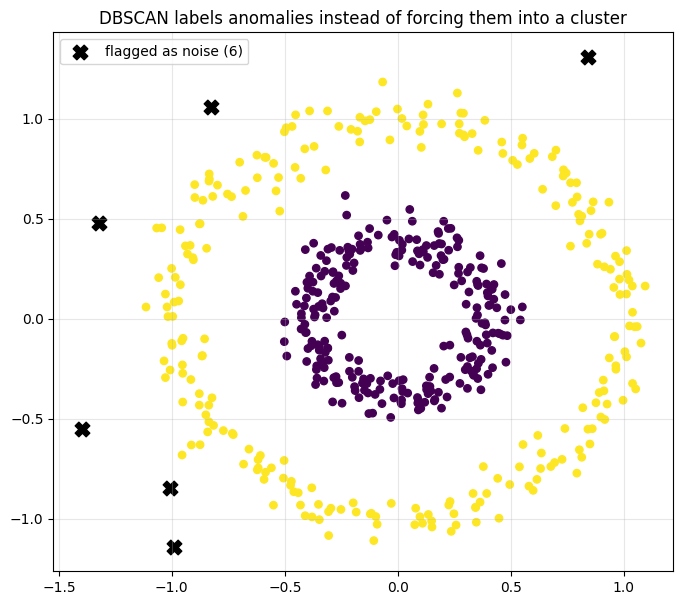

In [ ]:
rng = np.random.RandomState(1)
outliers = rng.uniform(-1.4, 1.4, size=(12, 2))
X_aug = np.vstack([X_rings, outliers])

labels_aug = DBSCAN(eps=0.16, min_samples=5).fit_predict(X_aug)
n_noise_aug = int((labels_aug == -1).sum())
caught = int((labels_aug[-12:] == -1).sum())

print('injected anomalies            : 12')
print('points DBSCAN flagged as noise: %d' % n_noise_aug)
print('injected anomalies caught     : %d of 12' % caught)
print('clusters still found          : %d'
      % (len(set(labels_aug)) - (1 if -1 in labels_aug else 0)))
print('ARI on the 500 original points: %.3f' % adjusted_rand_score(y_rings, labels_aug[:500]))

plt.figure(figsize=(8, 7))
core = labels_aug != -1
plt.scatter(X_aug[core, 0], X_aug[core, 1], c=labels_aug[core], cmap='viridis', s=28)
plt.scatter(X_aug[~core, 0], X_aug[~core, 1], c='black', s=110, marker='X',
            label='flagged as noise (%d)' % n_noise_aug)
plt.title('DBSCAN labels anomalies instead of forcing them into a cluster')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Conclusion.** DBSCAN flagged **6** points as noise, and all 6 are injected anomalies. The
two rings survive untouched - ARI on the original 500 points is still **1.000**.

**Why only 6 of 12?** The other six landed by chance on top of a ring, among enough real
points to be dense. They are not detectable as anomalies *from geometry alone*, and DBSCAN is
right not to flag them. An honest anomaly detector finds the points that are actually
isolated, not the ones you happen to have labelled.

**Contrast with K-Means, which has no concept of noise.** Every point gets a cluster, always.
An outlier is not just missed - it is absorbed into a cluster and **drags that cluster's
centroid towards itself**, corrupting a segment you were going to act on. For fraud
screening, "belongs to nothing" is the most valuable label available.

## 5.2 Choosing eps: the k-distance graph

`eps` is DBSCAN's hard parameter, and the wrong value fails in both directions: too small and
everything becomes noise; too large and separate clusters merge into one.

Slide 136 gives the recipe:

1. **MinPts** rule of thumb: about $2 \times$ the number of dimensions. For 2-D data, start
   around 4-5.
2. **eps**: compute each point's distance to its *k*-th nearest neighbour, sort those
   distances, and plot them. The **knee** of that curve is a good `eps`.

The logic: below the knee, distances grow slowly because you are still inside dense regions.
Above it they climb steeply - those are the isolated points. The knee is the boundary between
"dense" and "sparse" for this dataset.

median 5th-NN distance : 0.071
90th percentile         : 0.115
99th percentile         : 0.154


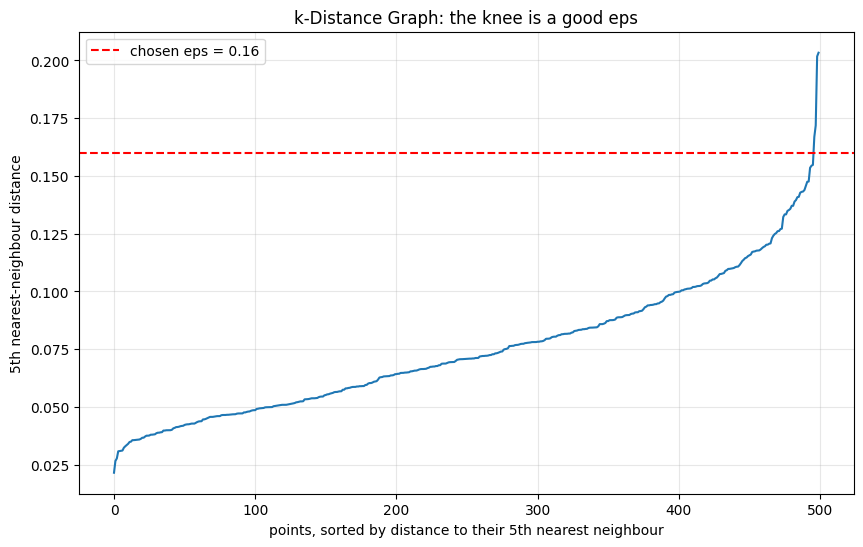

In [ ]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_rings)
distances, _ = nn.kneighbors(X_rings)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_dist)
plt.axhline(0.16, color='red', ls='--', label='chosen eps = 0.16')
plt.xlabel('points, sorted by distance to their %dth nearest neighbour' % min_samples)
plt.ylabel('%dth nearest-neighbour distance' % min_samples)
plt.title('k-Distance Graph: the knee is a good eps')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print('median %dth-NN distance : %.3f' % (min_samples, np.percentile(k_dist, 50)))
print('90th percentile         : %.3f' % np.percentile(k_dist, 90))
print('99th percentile         : %.3f' % np.percentile(k_dist, 99))

In [ ]:
print('What actually happens as eps varies:')
print(' %6s %10s %8s %8s' % ('eps', 'clusters', 'noise', 'ARI'))
for eps in [0.06, 0.08, 0.10, 0.12, 0.16, 0.20, 0.30, 0.40, 0.50]:
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_rings)
    k = len(set(lab)) - (1 if -1 in lab else 0)
    print(' %6.2f %10d %8d %8.3f'
          % (eps, k, int((lab == -1).sum()), adjusted_rand_score(y_rings, lab)))

What actually happens as eps varies:
    eps   clusters    noise      ARI
   0.06         16      239    0.312
   0.08         19      104    0.542
   0.10         16       18    0.546
   0.12          4        3    0.928
   0.16          2        0    1.000
   0.20          2        0    1.000
   0.30          2        0    1.000
   0.40          1        0    0.000
   0.50          1        0    0.000


**Conclusion.** The sweep shows exactly the two failure modes.

* **eps too small (0.06 - 0.10):** the algorithm cannot connect neighbouring points, so it
  shatters the rings into 16-19 fragments and labels up to **239 of the 500 points** as noise.
* **eps in the working range (0.16 - 0.30):** exactly two clusters, ARI **1.000**. This is the
  answer.
* **eps too large (0.40 and above):** the radius now bridges the gap between the rings, they
  merge into **one** cluster, and the ARI collapses to **0.000**.

**This is the honest cost of DBSCAN.** It saved you from choosing K, but it made you choose
`eps` instead, and `eps` is far less intuitive - it is a distance in feature space, not a
count you can reason about.

The working range here is generous, anything from 0.16 to 0.30. But it is bounded on both
sides, and **nothing in the output tells you when you have left it**: at `eps = 0.40` DBSCAN
reports one clean cluster and zero noise points, which looks exactly like success. The
k-distance graph gives you a principled starting point; the sweep above is what confirms it.
Never ship a DBSCAN you have not swept.

| | K-Means | DBSCAN |
|---|---|---|
| number of clusters | you choose K | found automatically |
| cluster shape | convex only | any shape |
| outliers | forced into a cluster | labelled as noise |
| main parameter | K (elbow + silhouette help) | eps (k-distance graph helps) |
| scaling required | yes | yes - `eps` is a distance |
| struggles when | clusters are non-convex or uneven | clusters have different densities |

**Note the last row of the scaling column.** `eps` is measured in the units of your features.
On unscaled data "a radius of 0.16" is meaningless when one column runs to tens of thousands.
DBSCAN needs a `StandardScaler` just as much as K-Means does.

---
# What to take away

| | |
|---|---|
| **SVM margin** | The widest-margin boundary, resting on a handful of support vectors. |
| **`C`** | The price of a margin violation. Small C = wide margin, many support vectors, more bias. |
| **Kernels** | An assumption about the shape of the boundary. Degree-2 nailed the circle; degree-3 failed. RBF adapts without being told. |
| **`gamma`** | The overfitting dial. Support vectors approaching the training-set size is your warning light. |
| **K-Means** | Fast and convex-only. Converges to a local optimum, so use `n_init` and `k-means++`. |
| **Choosing K** | Elbow and silhouette, cross-checked. Neither proves clusters exist. |
| **DBSCAN** | Density, any shape, and it can say "noise". You trade choosing K for choosing eps. |
| **Scaling** | Required by every single method in this notebook. |

**The thread running through the whole week:** SVM, K-Means and DBSCAN all reduce to
measuring how far apart two points are. That makes them powerful on geometry that linear
models cannot touch - and it makes every one of them worthless if your features are in
mismatched units. Put a `StandardScaler` in a `Pipeline` and stop thinking about it.

---
# Homework: Week 3 - Customer Segmentation

## Dataset: The Mall Customers
You are a data scientist for a large retail company. You have data on customers including
age, annual income, and a spending score.

**URL:** https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv

```python
import pandas as pd
URL = ('https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/'
       'Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/'
       'Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv')
df = pd.read_csv(URL)
```

## Part 1: Exploration & Preprocessing
1. Load the CSV and drop `CustomerID` (it is just an identifier, and clustering on it would
   be meaningless).
2. Show `.head()`, `.info()` and `.describe()`.
3. Report `df.std()` for the two features you are about to cluster on. **How many times
   larger is the spread of income than the spread of spending score?** You will refer back
   to this number in Part 2.

## Part 2: Features & Scaling
- Cluster on these two features:
  - `Annual Income (k$)`
  - `Spending Score (1-100)`
- Build `X` with those columns and standardise with `StandardScaler`.
- **Then do it wrong on purpose, once.** Fit K-Means with K=5 on the *unscaled* `X` as well,
  and describe the five clusters it produces (min and max income, min and max spending score
  for each). Compare them with the scaled solution and say in two sentences what the unscaled
  version actually segmented on. Section 4.1 of this notebook is the worked template.

## Part 3: K-Means - choosing K
1. **Elbow:** for $K = 1 \dots 10$, fit K-Means on the **scaled** data and record
   `inertia_`. Plot WCSS against K. Add a column showing the percentage improvement each
   extra cluster buys - the elbow is much easier to defend with numbers than by eye.
2. **Silhouette:** for $K = 2 \dots 10$, compute the silhouette score and plot it.
3. Do the two methods agree? Say which K you are taking forward and why. If they disagree,
   say what that disagreement tells you.

Use `init='k-means++'`, `n_init=10` and a fixed `random_state` throughout, so your results
are reproducible and so you are not at the mercy of one unlucky initialisation.

## Part 4: Final K-Means Model (K = 5) & Strategy
- Fit K-Means with $K=5$ on the scaled data and attach the labels to the original DataFrame.
- Scatter plot: income on the x-axis, spending score on the y-axis, coloured by cluster,
  with the centroids marked. **Plot in the original units, not the scaled ones** - nobody can
  interpret a centroid at -0.83.
- Build a profile table: for each cluster, the mean Age, mean Annual Income, mean Spending
  Score, and the number of customers.
- Write two or three sentences per cluster:
  - Who is in it (age, income, spending pattern)?
  - What would you actually do about them (product, channel, marketing focus)?
- **Give each cluster a name a marketing manager would use.** "Cluster 3" is not a segment;
  "high income, low engagement" is.

## Part 5: DBSCAN on the same customers
- Same two features, **scaled** (`eps` is a distance, so it is meaningless on raw units).
- Choose `min_samples` using the rule of thumb from slide 136, then find `eps` with a
  **k-distance graph**: plot the sorted distance to the `min_samples`-th nearest neighbour
  and look for the knee.
- **Sweep `eps`** over a range around your knee and tabulate, for each value: the number of
  clusters, the number of noise points, and the silhouette score. Pick a value in the knee
  region that gives a sensible number of clusters plus some noise, and justify it from your
  table rather than from a single lucky run.
- Plot the customers coloured by DBSCAN cluster, with noise points in black.
- Build the same profile table as in Part 4 and compare it with the K-Means segments.
- **Look at the customers DBSCAN called noise.** Print their rows. Who are they, and is
  "belongs to no segment" a reasonable description of them?

## Part 6: The comparison
Answer in a short paragraph each:
- Which algorithm was easier to tune, and what exactly did you have to choose for each?
- Which produced segments that are more interpretable for marketing?
- DBSCAN can refuse to classify a customer. For **this** task, is that a feature or a
  problem? Would your answer change if the task were fraud detection instead of marketing?
- Which would you deploy for this segmentation task, and why?

## What is being assessed
The plots are the easy part. The marks are in Part 2's comparison, Part 3's justification of
K, the segment names in Part 4, and the reasoning in Part 6. A notebook that produces every
chart and explains none of them is missing the point of the exercise.